# Notebook 03 - Exploratory Data Analysis (EDA)

Notebook này thực hiện phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA) trên bộ dữ liệu khảo sát sinh viên Việt Nam sau khi đã hoàn thành quá trình làm sạch và tiền xử lý ở Notebook 02.

Mục tiêu của notebook là cung cấp cái nhìn tổng quan về đặc điểm dữ liệu, phân bố của các biến nghiên cứu, mối quan hệ giữa các biến cũng như đặc điểm của Digital Burnout trong bộ dữ liệu khảo sát.

Các kết quả của notebook sẽ là cơ sở cho quá trình đánh giá đặc trưng (Feature Validation) ở Notebook 04.

# 0. Set Up

Thiết lập môi trường làm việc, import các thư viện cần thiết và cấu hình hiển thị phục vụ quá trình Exploratory Data Analysis.

In [2]:
# Import các thư viện cần thiết

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Ẩn cảnh báo không cần thiết

warnings.filterwarnings("ignore")

# Thiết lập hiển thị dữ liệu

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

# Thiết lập hiển thị biểu đồ

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["figure.dpi"] = 100

# Thiết lập style chung cho biểu đồ

sns.set_theme(
    style="whitegrid"
)

# 1. Load Dataset

Đọc bộ dữ liệu đã được làm sạch từ Notebook 02 và kiểm tra thông tin tổng quan trước khi thực hiện Exploratory Data Analysis.

In [3]:
# Đường dẫn đến dataset đã xử lý

data_path = "../../data/processed/vietnam_dataset/vn_digital_burnout_cleaned.csv"

# Load dataset

survey_dataset = pd.read_csv(
    data_path
)

# Kiểm tra thông tin cơ bản

print("Đã load dataset thành công!")
print("Kích thước dataset:", survey_dataset.shape)

Đã load dataset thành công!
Kích thước dataset: (654, 30)


In [4]:
# Hiển thị một số dòng đầu tiên

survey_dataset.head()

,gender,birth_year,education_stage,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality,motivation_level,digital_exhaustion,digital_stress,physical_fatigue,emotional_exhaustion,performance_decline,loss_of_interest,burnout_symptom_score,digital_burnout_score,dbi_level,dbi_level_encoded
0,Nữ,2006 - 2008,Sinh viên đại học / cao đẳng (năm 3-4+),Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,"Chủ yếu để học (LMS, tài liệu, nghiên cứu)",1,1,5,3,2,2,1,9,4,4,4,2,2,7,9,4,2,4,4,2,1,2.833333,2.833333,Low,0
1,Nữ,2000 - 2002,Sinh viên đại học / cao đẳng (năm 1-2),"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...",Chủ yếu giao tiếp nhóm và làm việc cộng tác,2,4,1,2,2,1,4,8,2,2,2,4,4,8,10,1,5,4,4,2,3,3.166667,3.166667,Moderate,1
2,Nam,2009 - 2012,Sinh viên đại học / cao đẳng (năm 1-2),"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...","Chủ yếu để học (LMS, tài liệu, nghiên cứu)",1,4,1,3,1,3,4,8,4,1,3,3,2,5,3,5,3,2,3,2,3,3.000000,3.000000,Moderate,1
3,Nữ,1997 - 1999,Đã đi làm toàn thời gian,Hoàn toàn online / remote,"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",3,4,4,4,2,1,2,10,2,1,2,2,2,7,2,5,2,4,4,3,1,3.166667,3.166667,Moderate,1
4,Nam,2003 - 2005,Sinh viên đại học / cao đẳng (năm 3-4+),"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...",Chủ yếu giao tiếp nhóm và làm việc cộng tác,5,1,2,4,4,1,1,3,4,3,2,3,2,6,10,4,3,5,1,2,4,3.166667,3.166667,Moderate,1


In [5]:
# Kiểm tra các biến hiện có trong dataset

survey_dataset.columns.tolist()

['gender',
 'birth_year',
 'education_stage',
 'work_mode',
 'device_usage_type',
 'daily_screen_time',
 'social_media_hours',
 'doomscrolling_duration',
 'late_night_device_usage',
 'notification_count',
 'smartphone_unlocks',
 'app_switch_frequency',
 'concentration_score',
 'distraction_frequency',
 'focus_sessions',
 'deep_work_hours',
 'task_completion_rate',
 'sleep_hours',
 'sleep_quality',
 'motivation_level',
 'digital_exhaustion',
 'digital_stress',
 'physical_fatigue',
 'emotional_exhaustion',
 'performance_decline',
 'loss_of_interest',
 'burnout_symptom_score',
 'digital_burnout_score',
 'dbi_level',
 'dbi_level_encoded']

# 2. Tổng quan Dataset

Kiểm tra cấu trúc tổng quan của bộ dữ liệu sau quá trình làm sạch và chuẩn hóa.

Mục tiêu:

- Xác nhận các nhóm biến trong framework Digital Burnout Index (DBI).
- Kiểm tra sự đầy đủ của các biến đầu vào và biến mục tiêu.
- Chuẩn bị cơ sở cho các bước phân tích EDA tiếp theo.

In [6]:
# Kiểm tra tổng quan dataset

print("Kích thước dataset:")
print(survey_dataset.shape)


print("\nSố lượng biến theo kiểu dữ liệu:")
print(survey_dataset.dtypes.value_counts())


print("\nDanh sách biến:")
print(survey_dataset.columns.tolist())

Kích thước dataset:
(654, 30)

Số lượng biến theo kiểu dữ liệu:
int64      22
object      6
float64     2
Name: count, dtype: int64

Danh sách biến:
['gender', 'birth_year', 'education_stage', 'work_mode', 'device_usage_type', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'late_night_device_usage', 'notification_count', 'smartphone_unlocks', 'app_switch_frequency', 'concentration_score', 'distraction_frequency', 'focus_sessions', 'deep_work_hours', 'task_completion_rate', 'sleep_hours', 'sleep_quality', 'motivation_level', 'digital_exhaustion', 'digital_stress', 'physical_fatigue', 'emotional_exhaustion', 'performance_decline', 'loss_of_interest', 'burnout_symptom_score', 'digital_burnout_score', 'dbi_level', 'dbi_level_encoded']


In [8]:
# Khai báo nhóm chỉ báo theo framework Digital Burnout Index (DBI)

indicator_groups = {

    "Demographic Variables": [
        "gender",
        "birth_year",
        "education_stage"
    ],

    "Context Variables": [
        "work_mode",
        "device_usage_type"
    ],

    "Digital Exposure Indicators": [
        "daily_screen_time",
        "social_media_hours",
        "doomscrolling_duration",
        "late_night_device_usage",
        "notification_count",
        "smartphone_unlocks",
        "app_switch_frequency"
    ],

    "Cognitive Performance Indicators": [
        "concentration_score",
        "distraction_frequency",
        "focus_sessions",
        "deep_work_hours",
        "task_completion_rate",
        "motivation_level"
    ],

    "Sleep & Recovery Indicators": [
        "sleep_hours",
        "sleep_quality"
    ],

    "Digital Burnout Scale Items": [
        "digital_exhaustion",
        "digital_stress",
        "physical_fatigue",
        "emotional_exhaustion",
        "performance_decline",
        "loss_of_interest"
    ],

    "Composite Indicators": [
        "burnout_symptom_score",
        "digital_burnout_score",
        "dbi_level",
        "dbi_level_encoded"
    ]
}

# Tạo bảng tổng quan nhóm chỉ báo

indicator_summary = pd.DataFrame({
    "Indicator Group": indicator_groups.keys(),
    "Number of Variables": [
        len(features)
        for features in indicator_groups.values()
    ]
})


indicator_summary

,Indicator Group,Number of Variables
0,Demographic Variables,3
1,Context Variables,2
2,Digital Exposure Indicators,7
3,Cognitive Performance Indicators,6
4,Sleep & Recovery Indicators,2
5,Digital Burnout Scale Items,6
6,Composite Indicators,4


# 3. Đặc điểm mẫu khảo sát


Phân tích đặc điểm tổng quan của nhóm người tham gia khảo sát nhằm hiểu bối cảnh dữ liệu trước khi đánh giá các yếu tố liên quan đến Digital Burnout.

Phần này tập trung phân tích hai nhóm biến:

- Demographic Variables:
    - Giới tính.
    - Năm sinh.
    - Giai đoạn học tập/làm việc.

- Context Variables:
    - Hình thức học tập/làm việc.
    - Cách sử dụng thiết bị số.

Các biến này được sử dụng để mô tả đặc điểm mẫu khảo sát và không tham gia trực tiếp vào quá trình tính toán Digital Burnout Score.

In [10]:
# Khai báo nhóm biến mô tả đặc điểm mẫu khảo sát

sample_features = [
    "gender",
    "birth_year",
    "education_stage",
    "work_mode",
    "device_usage_type"
]


# Thống kê phân bố của các biến đặc điểm mẫu

sample_distribution = {}

for feature in sample_features:
    
    sample_distribution[feature] = (
        survey_dataset[feature]
        .value_counts()
        .reset_index()
    )
    
    sample_distribution[feature].columns = [
        feature,
        "Count"
    ]


sample_distribution

{'gender':   gender  Count
 0     Nữ    415
 1    Nam    239,
 'birth_year':     birth_year  Count
 0  2003 - 2005    254
 1  2006 - 2008    174
 2  2000 - 2002    121
 3  2009 - 2012     59
 4  1997 - 1999     46,
 'education_stage':                            education_stage  Count
 0  Sinh viên đại học / cao đẳng (năm 3-4+)    243
 1   Sinh viên đại học / cao đẳng (năm 1-2)    208
 2                            Học sinh THPT     59
 3            Vừa học vừa đi làm / thực tập     57
 4                 Đã đi làm toàn thời gian     45
 5               Freelancer / tự kinh doanh     35
 6                                     Khác      7,
 'work_mode':                                            work_mode  Count
 0  Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...    484
 1  Kết hợp hybrid (2-3 ngày trực tiếp, còn lại on...    122
 2                          Hoàn toàn online / remote     46
 3                    Tự do, không cố định lịch trình      2,
 'device_usage_type':                 

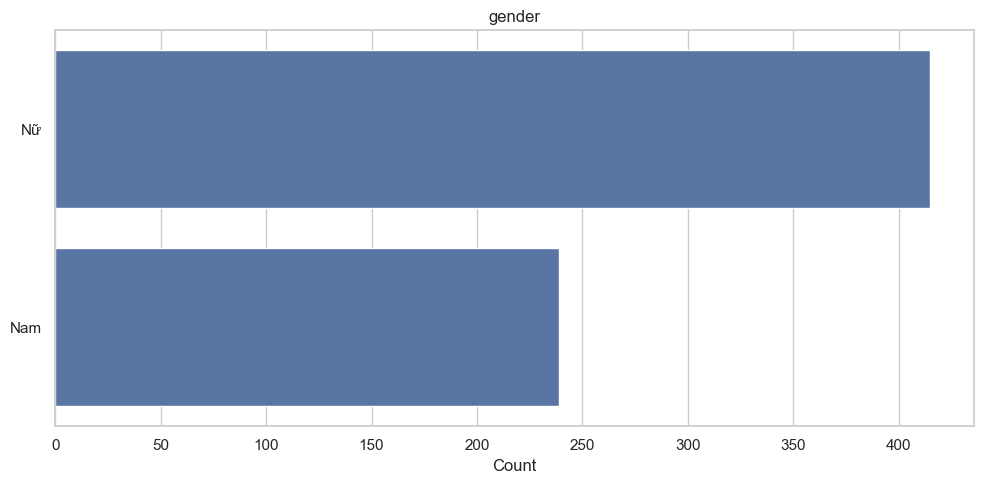

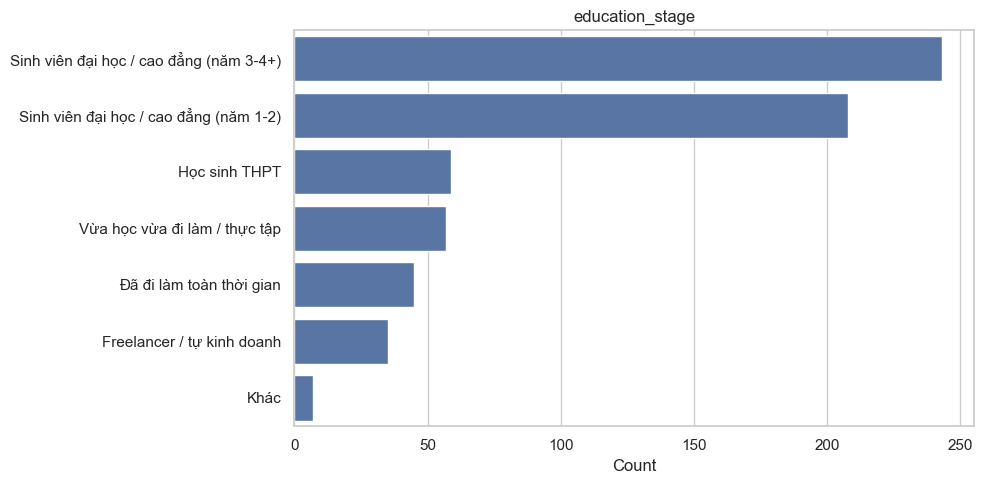

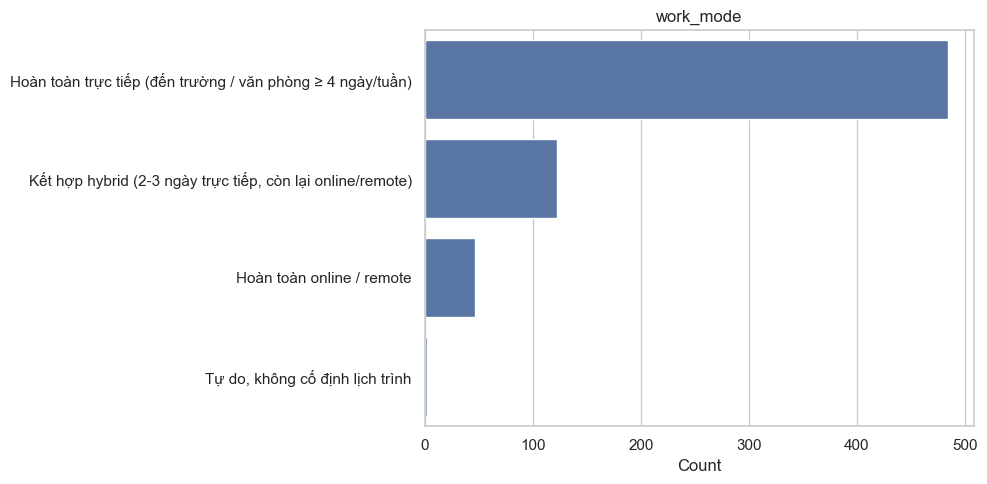

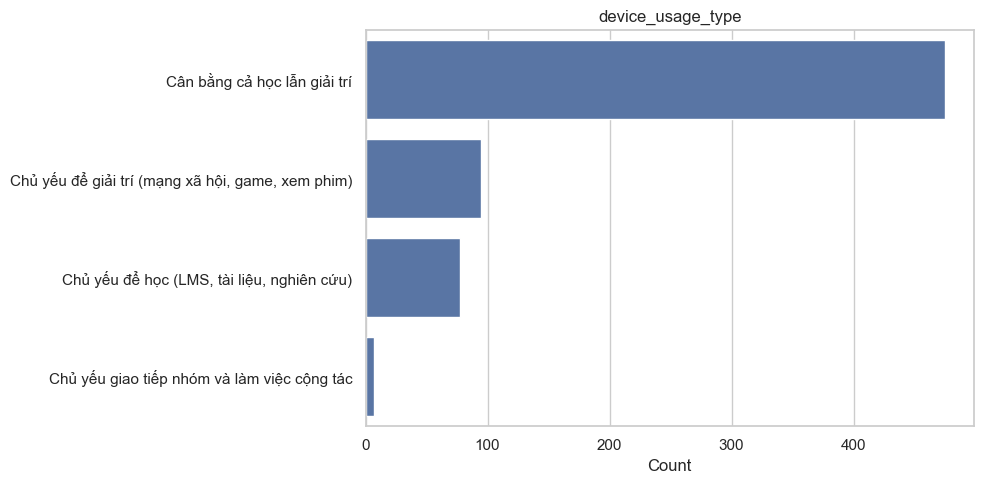

In [12]:
# Vẽ biểu đồ phân bố đặc điểm mẫu khảo sát

plot_features = [
    "gender",
    "education_stage",
    "work_mode",
    "device_usage_type"
]


for feature in plot_features:
    
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=survey_dataset,
        y=feature,
        order=survey_dataset[feature].value_counts().index
    )
    
    plt.title(feature)
    plt.xlabel("Count")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

# 4. Digital Exposure

Phân tích các hành vi sử dụng thiết bị số của người tham gia khảo sát nhằm đánh giá mức độ tiếp xúc kỹ thuật số trong framework Digital Burnout Index (DBI).

Nhóm Digital Exposure Indicators được phân tích bao gồm:

- daily_screen_time: Tổng thời gian sử dụng thiết bị số mỗi ngày.
- social_media_hours: Thời gian sử dụng mạng xã hội.
- doomscrolling_duration: Thời lượng sử dụng nội dung số liên tục không có mục đích rõ ràng.
- late_night_device_usage: Mức độ sử dụng thiết bị vào ban đêm.
- notification_count: Số lượng thông báo nhận được mỗi ngày.
- smartphone_unlocks: Số lần mở khóa điện thoại.
- app_switch_frequency: Tần suất chuyển đổi giữa các ứng dụng.

In [13]:
# Khai báo các biến thuộc nhóm Digital Exposure Indicators

digital_exposure_features = [
    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "late_night_device_usage",
    "notification_count",
    "smartphone_unlocks",
    "app_switch_frequency"
]


# Kiểm tra phân bố của các biến Digital Exposure

for feature in digital_exposure_features:
    
    print(f"\n{feature}")
    
    display(
        survey_dataset[feature]
        .value_counts()
        .reset_index()
    )


daily_screen_time


,daily_screen_time,count
0,4,254
1,5,217
2,2,97
3,3,79
4,1,7



social_media_hours


,social_media_hours,count
0,3,270
1,4,202
2,2,159
3,1,23



doomscrolling_duration


...

,notification_count,count
0,2,248
1,1,188
2,3,133
3,4,85



smartphone_unlocks


,smartphone_unlocks,count
0,2,306
1,3,197
2,4,91
3,1,60



app_switch_frequency


,app_switch_frequency,count
0,2,246
1,1,179
2,3,150
3,4,79


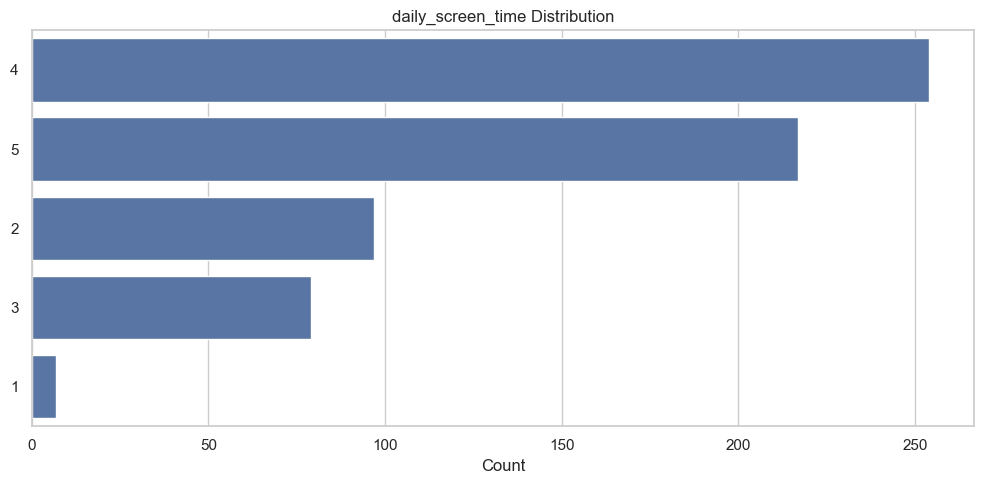

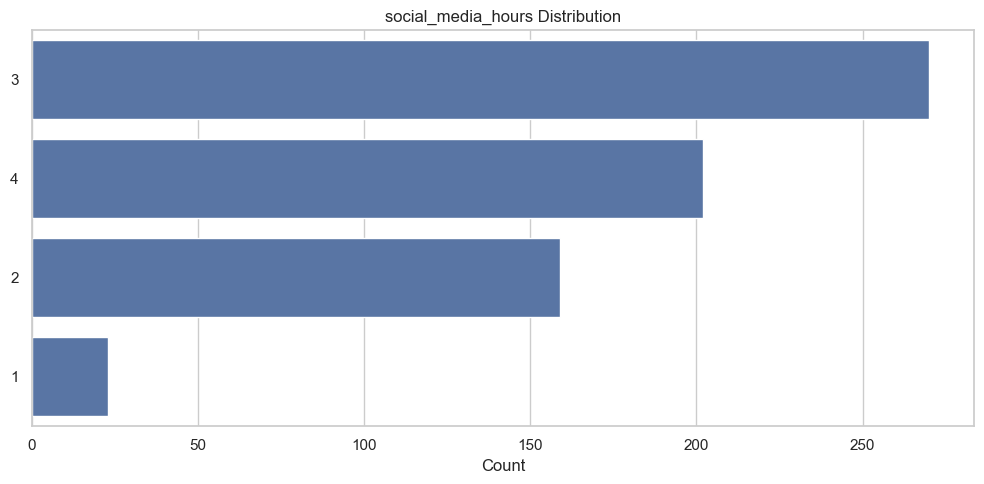

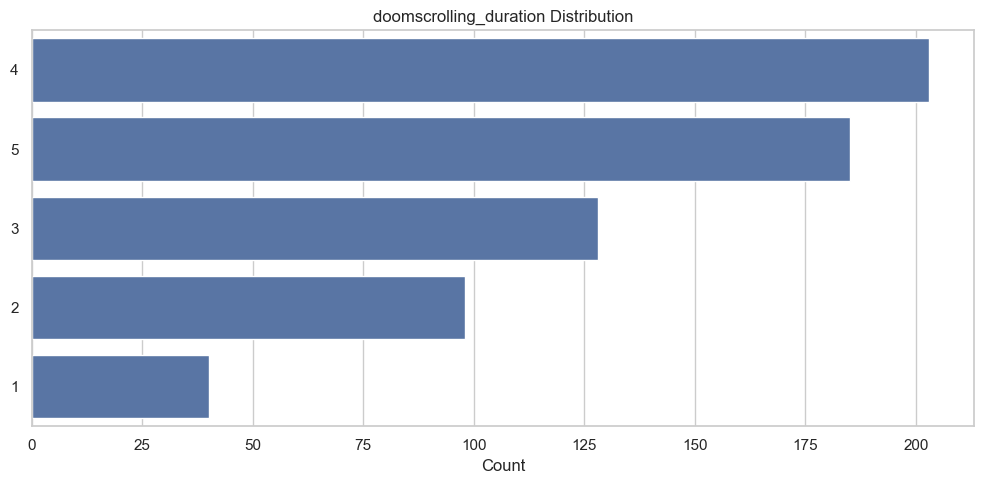

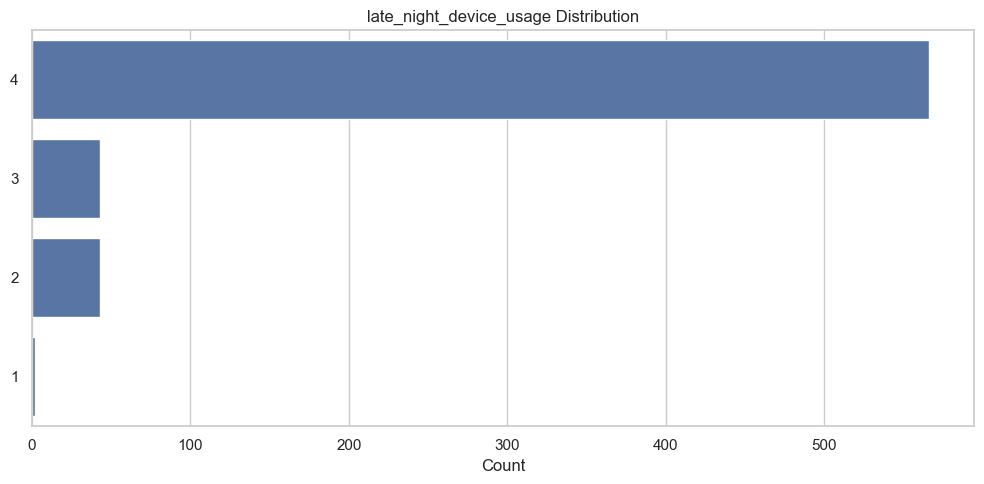

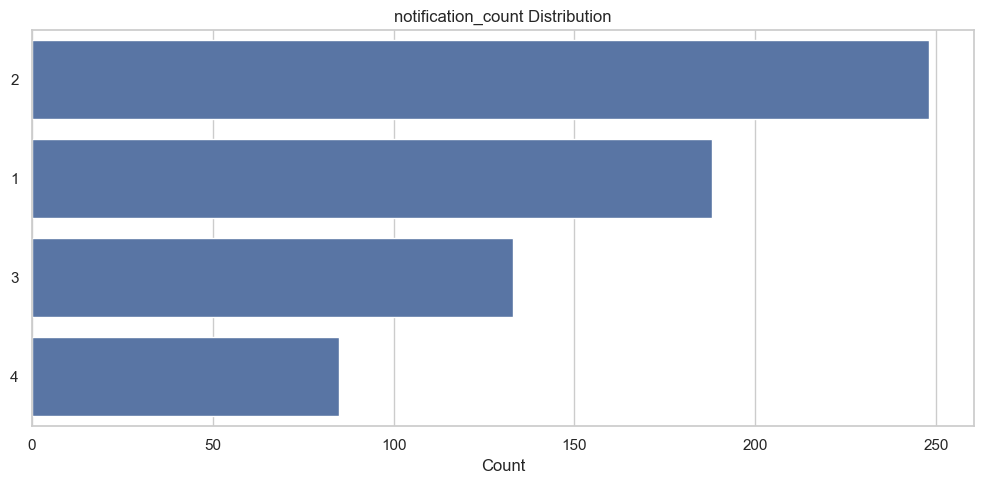

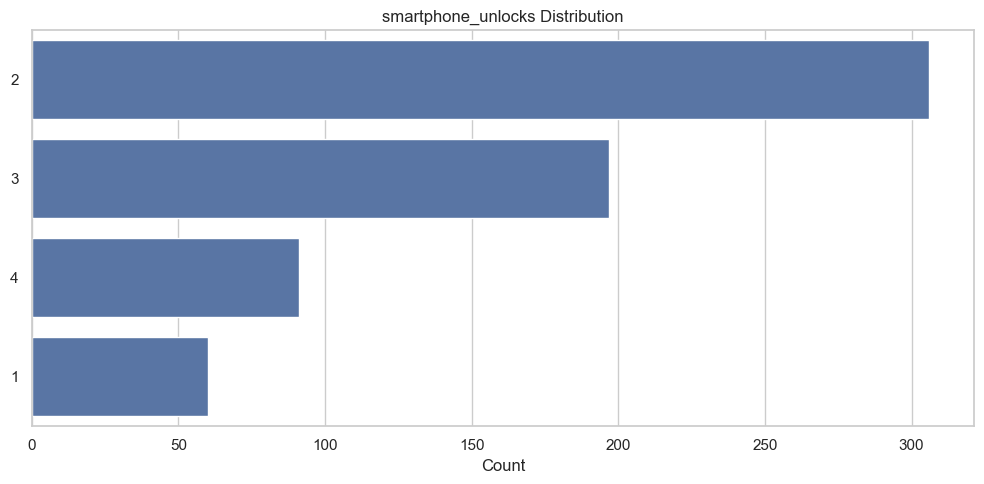

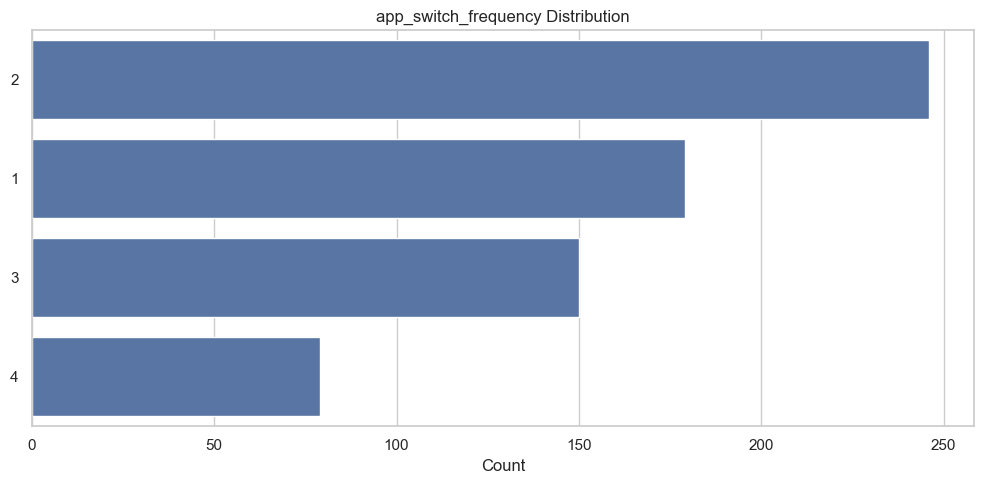

In [14]:
# Vẽ biểu đồ phân bố các chỉ báo Digital Exposure

for feature in digital_exposure_features:
    
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=survey_dataset,
        y=feature,
        order=survey_dataset[feature].value_counts().index
    )
    
    plt.title(f"{feature} Distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

# 5. Cognitive Performance

Phân tích khả năng tập trung, kiểm soát sự phân tâm và duy trì hiệu suất làm việc/học tập của người tham gia khảo sát.

Nhóm Cognitive Performance Indicators được phân tích bao gồm:

- concentration_score: Mức độ tự đánh giá khả năng tập trung.
- distraction_frequency: Tần suất bị gián đoạn trong quá trình học tập/làm việc.
- focus_sessions: Số phiên tập trung liên tục trong ngày.
- deep_work_hours: Thời gian dành cho hoạt động tập trung sâu.
- task_completion_rate: Mức độ hoàn thành nhiệm vụ.
- motivation_level: Mức độ động lực học tập/làm việc.

In [15]:
# Khai báo các biến thuộc nhóm Cognitive Performance Indicators

cognitive_features = [
    "concentration_score",
    "distraction_frequency",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate",
    "motivation_level"
]


# Kiểm tra phân bố các biến hiệu suất nhận thức

for feature in cognitive_features:
    
    print(f"\n{feature}")
    
    display(
        survey_dataset[feature]
        .value_counts()
        .reset_index()
    )


concentration_score


,concentration_score,count
0,6,167
1,5,117
2,7,104
3,4,68
4,1,45
5,8,45
6,2,33
7,3,30
8,10,24
9,9,21



distraction_frequency


,distraction_frequency,count
0,3,257
1,2,194
2,4,145
3,1,58



focus_sessions


...

,deep_work_hours,count
0,3,215
1,2,190
2,4,135
3,1,114



task_completion_rate


,task_completion_rate,count
0,2,227
1,3,177
2,1,173
3,4,77



motivation_level


,motivation_level,count
0,3,129
1,6,126
2,7,102
3,4,99
4,5,68
5,8,53
6,10,29
7,2,24
8,1,15
9,9,9


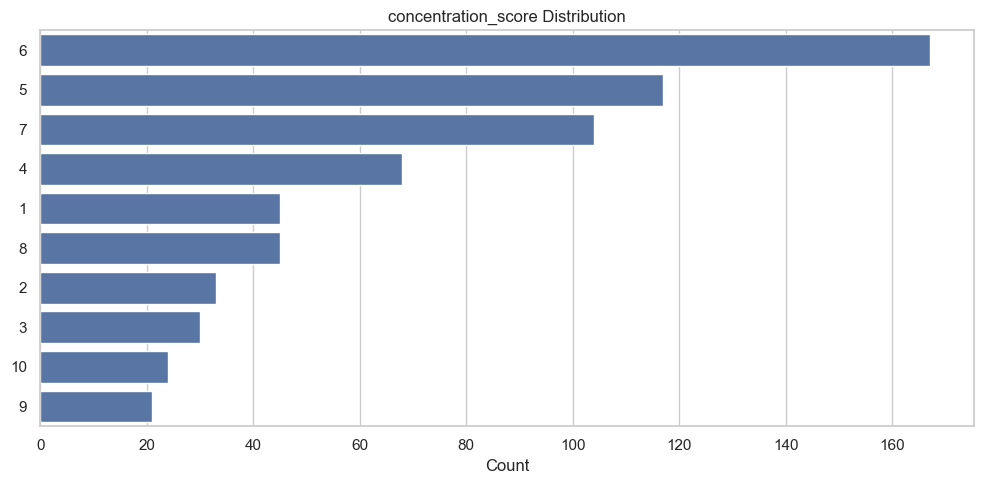

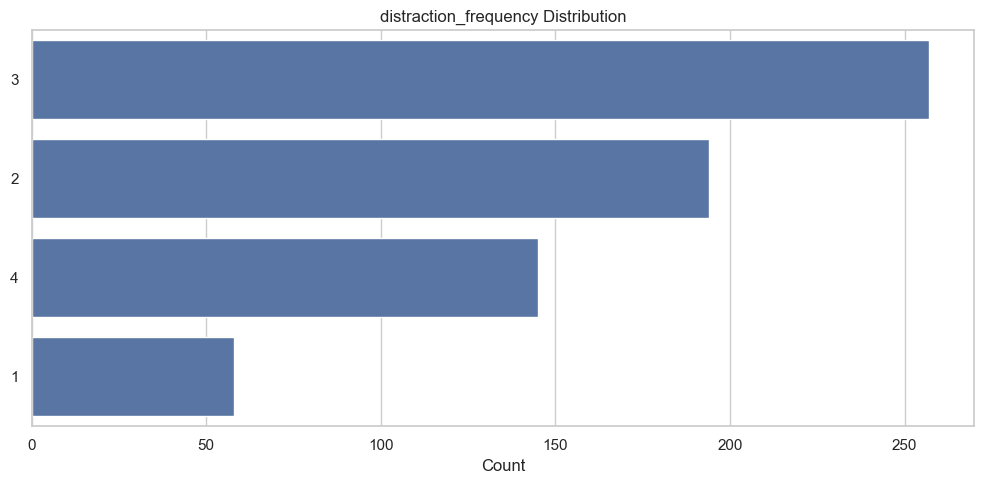

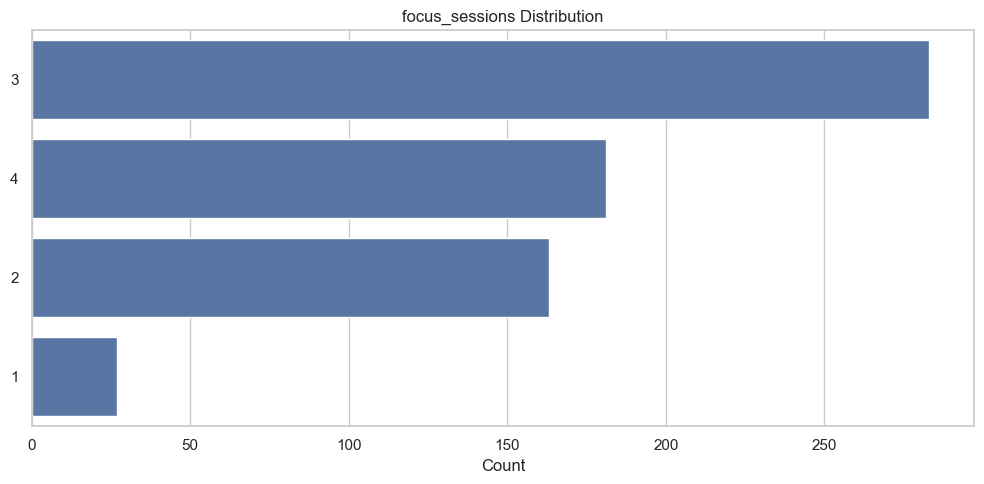

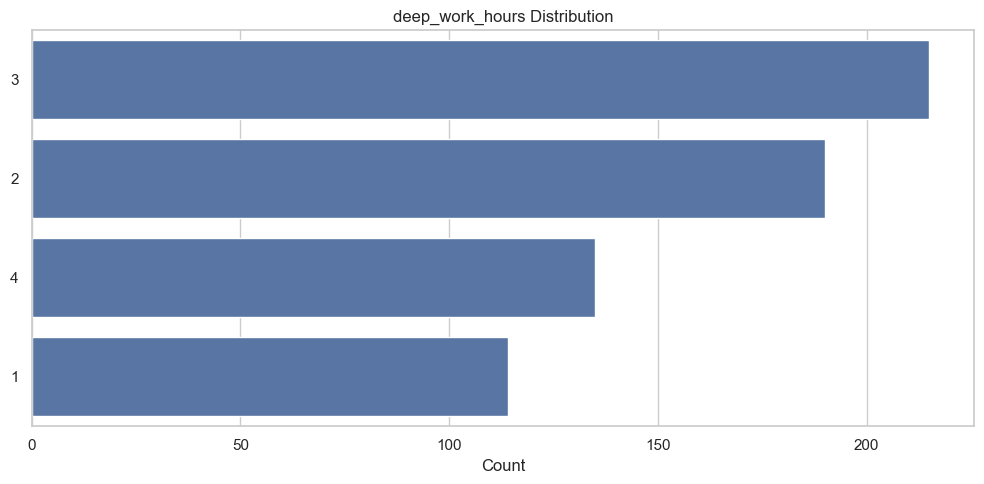

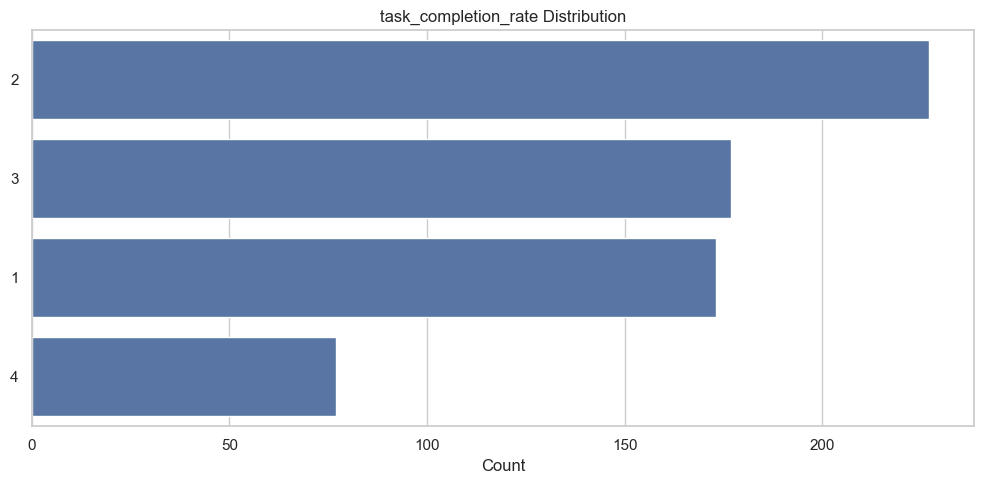

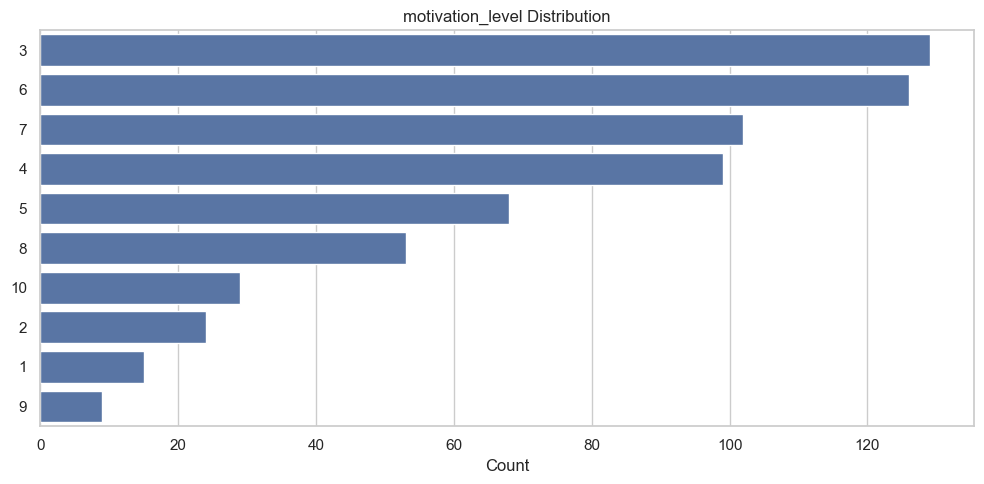

In [16]:
# Vẽ biểu đồ phân bố các chỉ báo hiệu suất nhận thức

for feature in cognitive_features:
    
    plt.figure(figsize=(10, 5))
    
    if survey_dataset[feature].nunique() <= 10:
        
        sns.countplot(
            data=survey_dataset,
            y=feature,
            order=survey_dataset[feature].value_counts().index
        )
    
    else:
        
        sns.histplot(
            data=survey_dataset,
            x=feature,
            bins=10
        )
    
    
    plt.title(f"{feature} Distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

# 6. Sleep & Recovery

Phân tích đặc điểm giấc ngủ và mức độ phục hồi của người tham gia nhằm đánh giá một trong các yếu tố quan trọng liên quan đến Digital Burnout.

Nhóm Sleep & Recovery Indicators được phân tích bao gồm:

- sleep_hours: Thời lượng ngủ trung bình mỗi ngày.

- sleep_quality: Mức độ đánh giá chất lượng giấc ngủ.

Các chỉ báo này phản ánh khả năng phục hồi thể chất và tinh thần sau thời gian tiếp xúc với môi trường số.

In [17]:
# Khai báo các biến thuộc nhóm Sleep & Recovery Indicators

sleep_features = [
    "sleep_hours",
    "sleep_quality"
]


# Kiểm tra phân bố các biến giấc ngủ và phục hồi

for feature in sleep_features:
    
    print(f"\n{feature}")
    
    display(
        survey_dataset[feature]
        .value_counts()
        .reset_index()
    )


sleep_hours


,sleep_hours,count
0,2,221
1,3,153
2,5,136
3,1,107
4,4,37



sleep_quality


,sleep_quality,count
0,4,164
1,6,130
2,5,88
3,3,85
4,7,62
5,8,47
6,2,29
7,9,27
8,1,12
9,10,10


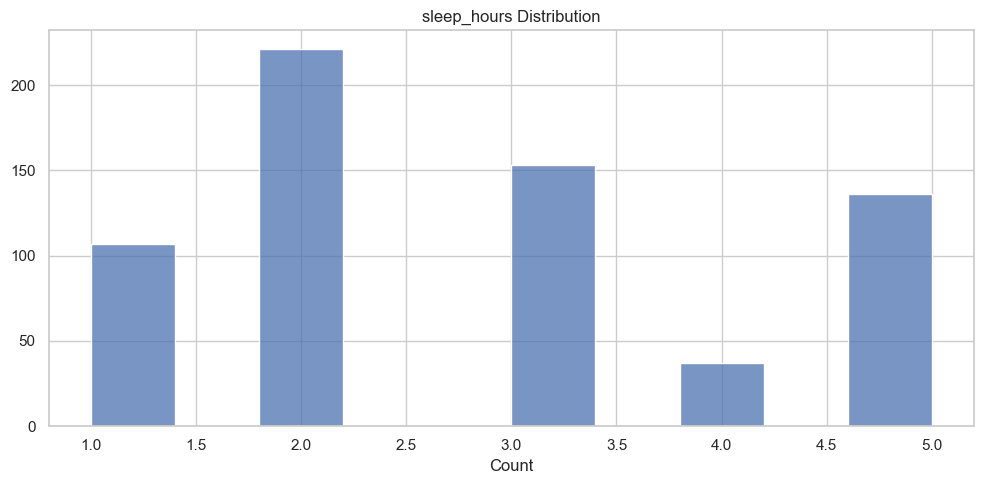

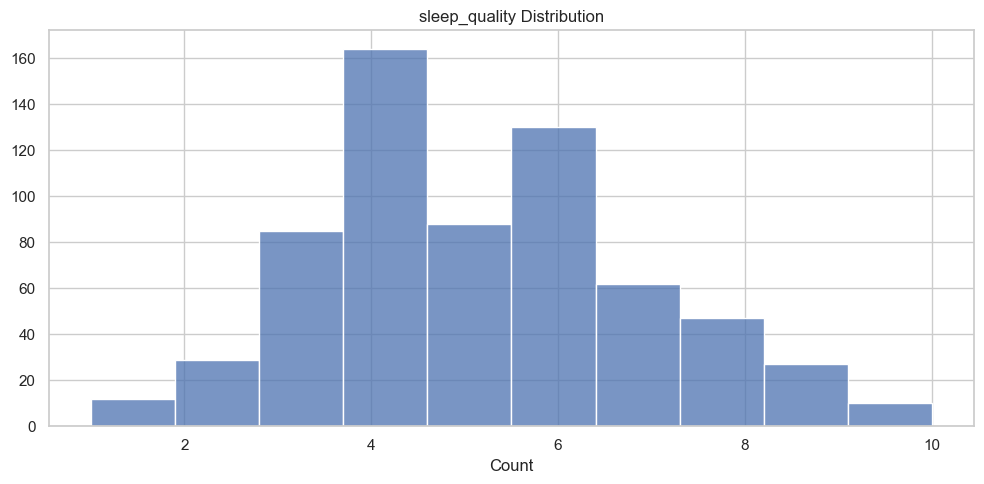

In [18]:
# Vẽ biểu đồ phân bố các chỉ báo giấc ngủ và phục hồi

for feature in sleep_features:
    
    plt.figure(figsize=(10, 5))
    
    if survey_dataset[feature].dtype == "object":
        
        sns.countplot(
            data=survey_dataset,
            y=feature,
            order=survey_dataset[feature].value_counts().index
        )
    
    else:
        
        sns.histplot(
            data=survey_dataset,
            x=feature,
            bins=10
        )
    
    
    plt.title(f"{feature} Distribution")
    plt.xlabel("Count")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

# 7. Digital Burnout Scale Items

Phân tích mức độ xuất hiện của các triệu chứng liên quan đến Digital Burnout trong nhóm người tham gia khảo sát.

Nhóm Digital Burnout Scale Items được sử dụng để đánh giá các biểu hiện trực tiếp của Digital Burnout, bao gồm:

- digital_exhaustion: Mức độ kiệt sức do sử dụng môi trường số.
- digital_stress: Mức độ căng thẳng liên quan đến hoạt động số.
- physical_fatigue: Mức độ mệt mỏi về thể chất.
- emotional_exhaustion: Mức độ cạn kiệt cảm xúc.
- performance_decline: Mức độ suy giảm hiệu suất.
- loss_of_interest: Mức độ mất hứng thú trong các hoạt động.

Các biến này được đo lường trên thang điểm Likert và là cơ sở để tổng hợp mức độ Digital Burnout.

In [19]:
# Khai báo các biến thuộc nhóm Digital Burnout Scale Items

burnout_symptom_features = [
    "digital_exhaustion",
    "digital_stress",
    "physical_fatigue",
    "emotional_exhaustion",
    "performance_decline",
    "loss_of_interest"
]


# Kiểm tra phân bố các triệu chứng Digital Burnout

for feature in burnout_symptom_features:
    
    print(f"\n{feature}")
    
    display(
        survey_dataset[feature]
        .value_counts()
        .sort_index()
        .reset_index()
    )


digital_exhaustion


,digital_exhaustion,count
0,1,24
1,2,60
2,3,184
3,4,256
4,5,130



digital_stress


,digital_stress,count
0,1,27
1,2,45
2,3,98
3,4,234
4,5,250



physical_fatigue


...

,emotional_exhaustion,count
0,1,30
1,2,78
2,3,250
3,4,174
4,5,122



performance_decline


,performance_decline,count
0,1,15
1,2,76
2,3,211
3,4,258
4,5,94



loss_of_interest


,loss_of_interest,count
0,1,20
1,2,187
2,3,187
3,4,213
4,5,47


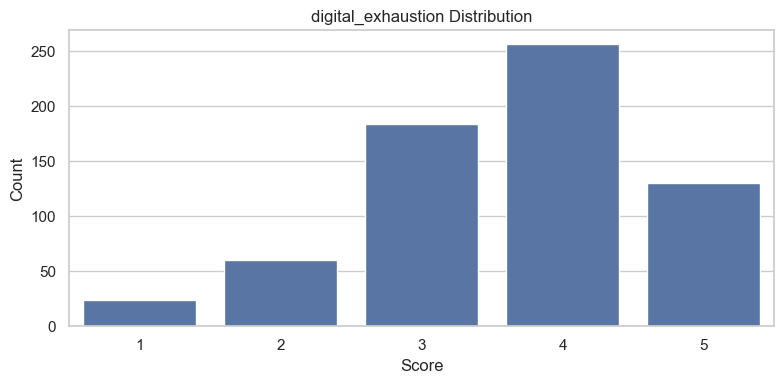

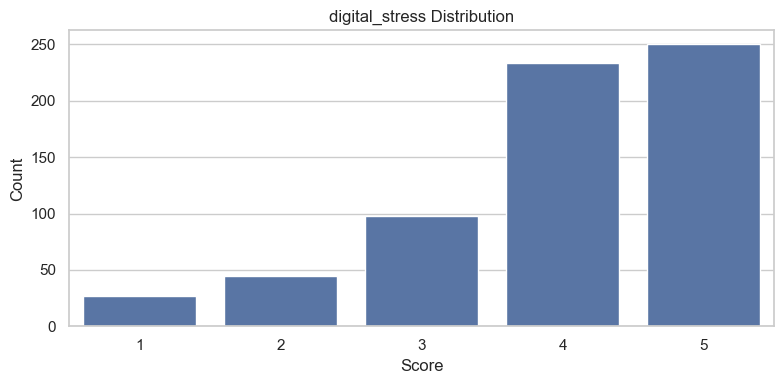

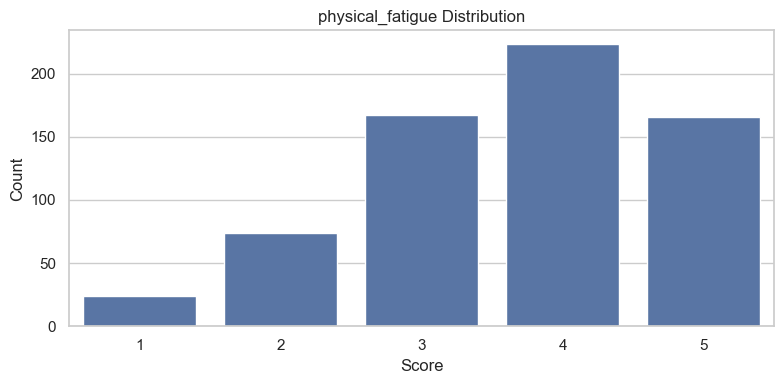

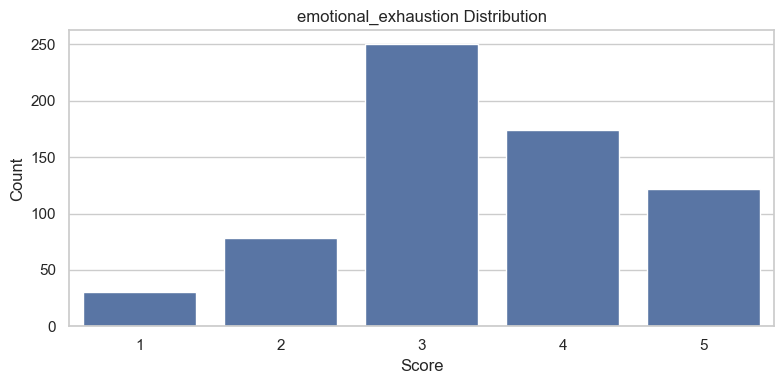

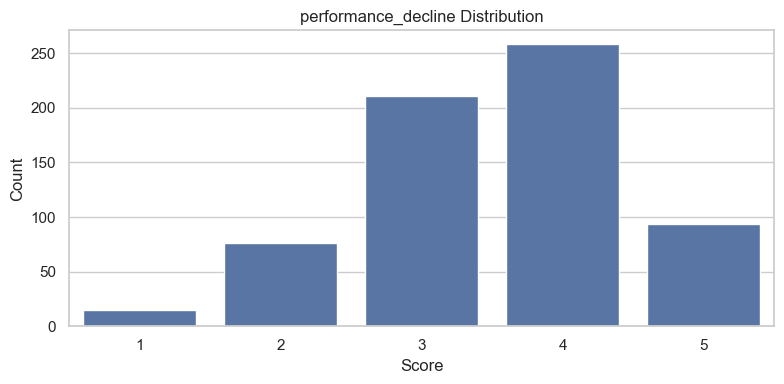

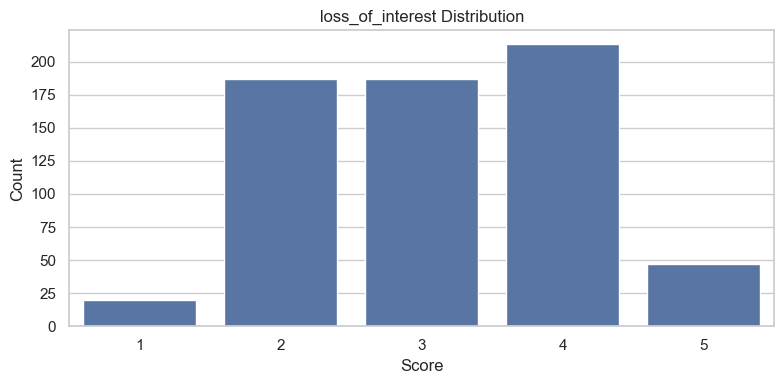

In [20]:
# Vẽ biểu đồ phân bố các triệu chứng Digital Burnout

for feature in burnout_symptom_features:
    
    plt.figure(figsize=(8, 4))
    
    sns.countplot(
        data=survey_dataset,
        x=feature,
        order=sorted(
            survey_dataset[feature].dropna().unique()
        )
    )
    
    plt.title(f"{feature} Distribution")
    plt.xlabel("Score")
    plt.ylabel("Count")
    
    plt.tight_layout()
    plt.show()

# 8. Composite Indicators

Phân tích mức độ Digital Burnout của mẫu khảo sát thông qua các chỉ số tổng hợp được xây dựng từ các nhóm chỉ báo DBI.

Các Composite Indicators được phân tích bao gồm:

- burnout_symptom_score: Điểm trung bình của nhóm triệu chứng Digital Burnout.
- digital_burnout_score: Chỉ số tổng hợp đại diện cho mức độ Digital Burnout.
- dbi_level: Phân loại mức độ Digital Burnout thành các nhóm:
    - Low.
    - Moderate.
    - High.

- dbi_level_encoded: Biến mã hóa phục vụ cho các bước phân tích định lượng và xây dựng mô hình.

Phần này giúp đánh giá mức độ burnout chung của nhóm khảo sát và kiểm tra sự phân bố của biến mục tiêu.

In [21]:
# Khai báo các biến tổng hợp Digital Burnout

composite_features = [
    "burnout_symptom_score",
    "digital_burnout_score",
    "dbi_level",
    "dbi_level_encoded"
]


# Kiểm tra thống kê mô tả các biến tổng hợp

survey_dataset[
    [
        "burnout_symptom_score",
        "digital_burnout_score"
    ]
].describe()

,burnout_symptom_score,digital_burnout_score
count,654.000000,654.000000
mean,3.554536,3.554536
std,0.462384,0.462384
min,1.166667,1.166667
25%,3.333333,3.333333
50%,3.666667,3.666667
75%,3.833333,3.833333
max,4.500000,4.500000


In [22]:
# Tính tỷ lệ phân bố các mức Digital Burnout

dbi_distribution = (
    survey_dataset["dbi_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)


# Đặt tên cột

dbi_distribution.columns = [
    "DBI Level",
    "Percentage"
]


dbi_distribution

,DBI Level,Percentage
0,Moderate,68.04
1,High,22.48
2,Low,9.48


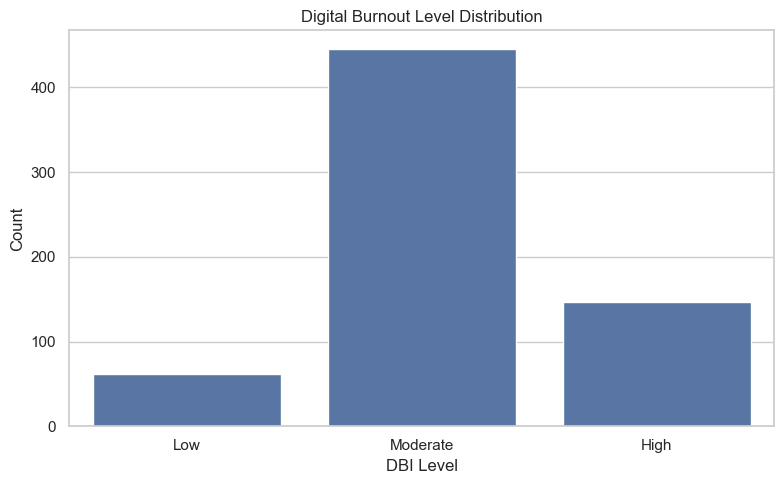

In [23]:
# Vẽ biểu đồ phân bố mức Digital Burnout

plt.figure(figsize=(8, 5))


sns.countplot(
    data=survey_dataset,
    x="dbi_level",
    order=[
        "Low",
        "Moderate",
        "High"
    ]
)


plt.title("Digital Burnout Level Distribution")
plt.xlabel("DBI Level")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

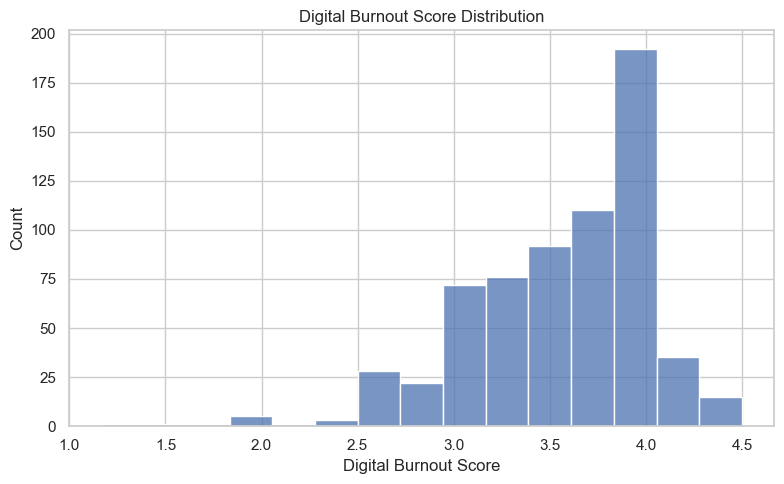

In [24]:
# Vẽ phân bố Digital Burnout Score

plt.figure(figsize=(8, 5))


sns.histplot(
    data=survey_dataset,
    x="digital_burnout_score",
    bins=15
)


plt.title("Digital Burnout Score Distribution")
plt.xlabel("Digital Burnout Score")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

# 9. Relationship Analysis

Đánh giá mối quan hệ giữa các nhóm chỉ báo trong framework Digital Burnout Index (DBI) với chỉ số Digital Burnout Score.

Phân tích tập trung vào:

- Mối quan hệ giữa các biến định lượng và digital_burnout_score.
- Mức độ tương quan giữa các chỉ báo và chỉ số tổng hợp.
- Nhận diện các nhóm yếu tố có xu hướng liên quan đến Digital Burnout.

Các phân tích trong phần này mang tính khám phá dữ liệu (Exploratory Analysis), không dùng để kết luận quan hệ nhân quả.

In [28]:
# Khai báo các biến định lượng phục vụ phân tích tương quan

correlation_features = [
    "concentration_score",
    "motivation_level",
    "sleep_quality",
    "digital_exhaustion",
    "digital_stress",
    "physical_fatigue",
    "emotional_exhaustion",
    "performance_decline",
    "loss_of_interest",
    "digital_burnout_score"
]


# Tính ma trận tương quan

correlation_matrix = (
    survey_dataset[correlation_features]
    .corr()
)


correlation_matrix

,concentration_score,motivation_level,sleep_quality,digital_exhaustion,digital_stress,physical_fatigue,emotional_exhaustion,performance_decline,loss_of_interest,digital_burnout_score
concentration_score,1.000000,-0.137282,-0.071463,-0.004587,0.105454,0.012360,-0.058155,-0.056063,-0.004675,0.001173
motivation_level,-0.137282,1.000000,-0.008004,-0.084114,-0.026583,-0.086855,-0.018763,-0.019132,0.012201,-0.084651
sleep_quality,-0.071463,-0.008004,1.000000,0.002803,-0.190460,-0.039194,-0.027567,-0.072197,-0.027897,-0.134363
digital_exhaustion,-0.004587,-0.084114,0.002803,1.000000,0.055163,0.051040,0.113431,0.092893,-0.064256,0.460911
digital_stress,0.105454,-0.026583,-0.190460,0.055163,1.000000,0.125365,0.066392,0.119630,0.014498,0.532684
physical_fatigue,0.012360,-0.086855,-0.039194,0.051040,0.125365,1.000000,-0.003155,0.079722,-0.064554,0.462135
emotional_exhaustion,-0.058155,-0.018763,-0.027567,0.113431,0.066392,-0.003155,1.000000,0.015747,-0.076294,0.427949
performance_decline,-0.056063,-0.019132,-0.072197,0.092893,0.119630,0.079722,0.015747,1.000000,0.055066,0.481687
loss_of_interest,-0.004675,0.012201,-0.027897,-0.064256,0.014498,-0.064554,-0.076294,0.055066,1.000000,0.308341
digital_burnout_score,0.001173,-0.084651,-0.134363,0.460911,0.532684,0.462135,0.427949,0.481687,0.308341,1.000000


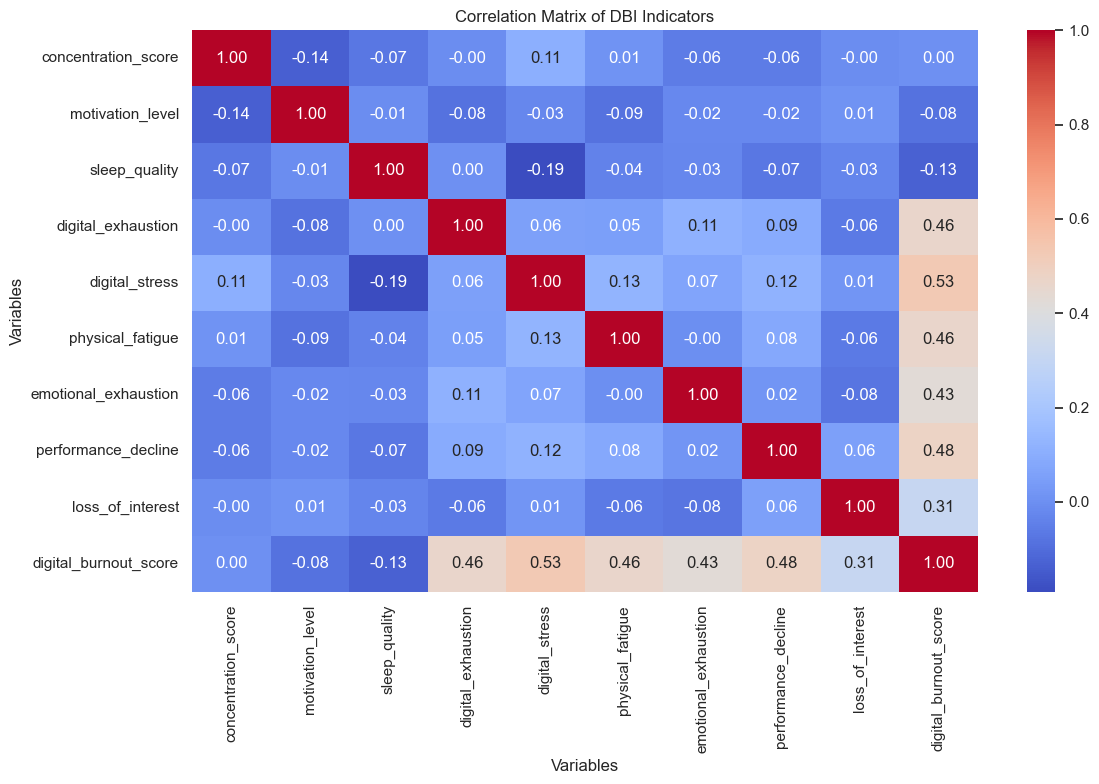

In [29]:
# Vẽ heatmap tương quan giữa các chỉ báo

plt.figure(figsize=(12, 8))


sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


plt.title("Correlation Matrix of DBI Indicators")
plt.xlabel("Variables")
plt.ylabel("Variables")


plt.tight_layout()
plt.show()

In [30]:
# Xếp hạng mức độ tương quan với Digital Burnout Score

burnout_correlation = (
    correlation_matrix["digital_burnout_score"]
    .drop("digital_burnout_score")
    .sort_values(
        ascending=False
    )
)


burnout_correlation

digital_stress          0.532684
performance_decline     0.481687
physical_fatigue        0.462135
digital_exhaustion      0.460911
emotional_exhaustion    0.427949
loss_of_interest        0.308341
concentration_score     0.001173
motivation_level       -0.084651
sleep_quality          -0.134363
Name: digital_burnout_score, dtype: float64

Kết quả phân tích tương quan cho thấy các chỉ báo thuộc nhóm Digital Burnout Scale Items có mức độ liên hệ rõ ràng với Digital Burnout Score.

Trong đó:

- digital_stress có mức tương quan dương cao nhất với digital_burnout_score (r = 0.53), cho thấy mức độ căng thẳng liên quan đến hoạt động số có liên hệ đáng kể với nguy cơ Digital Burnout.
- performance_decline (r = 0.48), physical_fatigue (r = 0.46) và digital_exhaustion (r = 0.46) cũng thể hiện mối liên hệ thuận chiều với Digital Burnout Score.
- emotional_exhaustion (r = 0.43) và loss_of_interest (r = 0.31) có mức tương quan thấp hơn nhưng vẫn thể hiện xu hướng cùng chiều với burnout.

Đối với các nhóm chỉ báo hỗ trợ:

- sleep_quality có tương quan âm nhẹ với Digital Burnout Score (r = -0.13), cho thấy chất lượng giấc ngủ tốt hơn có xu hướng liên quan đến mức burnout thấp hơn.
- concentration_score và motivation_level có mức tương quan rất thấp, cho thấy cần được đánh giá thêm thông qua các phương pháp khác như Feature Validation và Machine Learning.

Do digital_burnout_score được xây dựng trực tiếp từ các biến Digital Burnout Scale Items, mối tương quan cao giữa các biến này là kết quả hợp lý. Các phân tích tiếp theo trong Notebook 04 sẽ tập trung đánh giá mức độ đóng góp của các biến đầu vào thay vì chỉ dựa trên tương quan.